# Titanic Survival Prediction

## Project Overview

The goal of this project is to predict passenger survival on the Titanic dataset

In this notebook we will:
- Explore the dataset
- Preprocess the data
- Compare several classical machine learning models
- Evaluate them using multiple metrics
- Analyze model errors
- Tune the best-perfoming model
- Generate predictions for the Kaggle competition

## Notebook Structure

1. Data Loading
2. Exploratory Data Analysis
3. Data Preparation
4. Model Training
5. Model Evaluation
6. Error Analysis
7. Hyperparameter Tuning
8. Final Model
9. Kaggle Submission
10. Conclusion

## Data Loading and Initial Exploration

In [1]:
import pandas as pd

def load_titanic_data(filepath):
    return pd.read_csv(filepath)

In [2]:
titanic_data = load_titanic_data("/kaggle/input/competitions/titanic/train.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
titanic_data["PassengerId"].nunique()

891

In [5]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic_data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

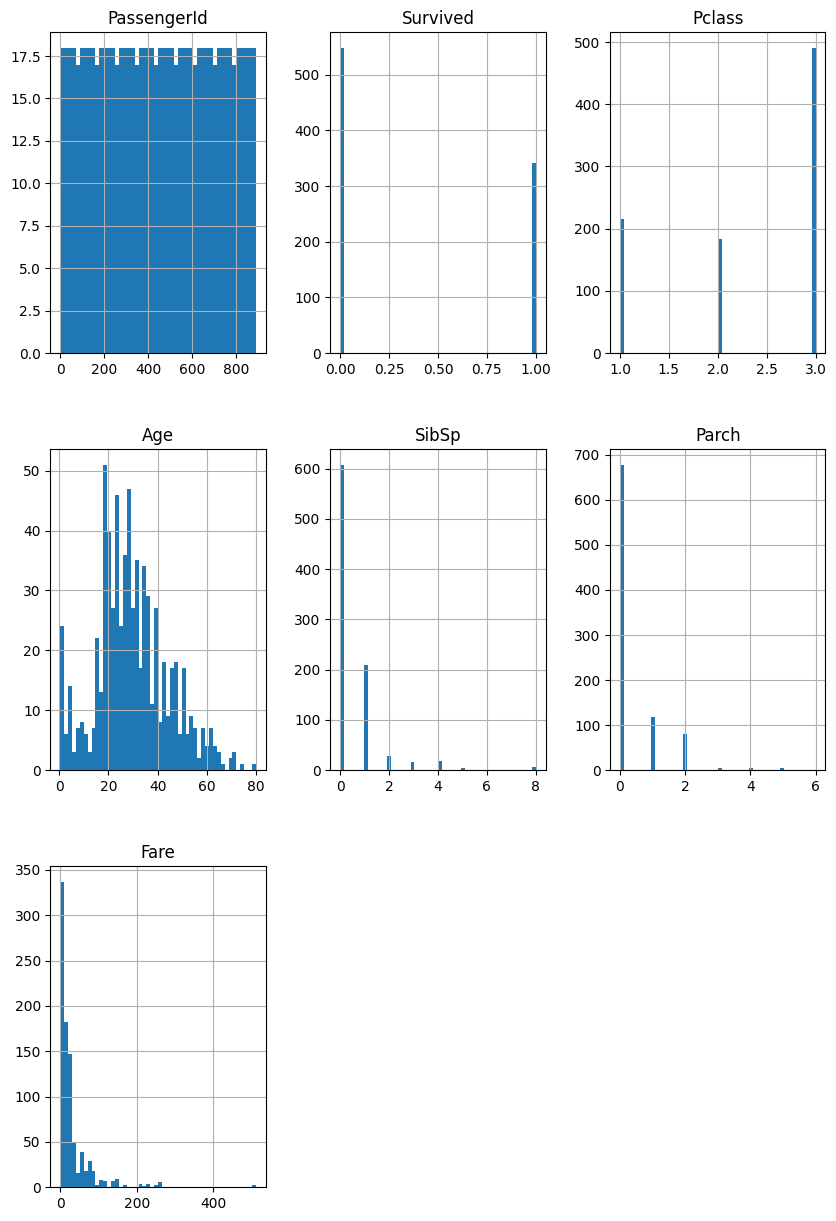

In [7]:
import matplotlib.pyplot as plt

%matplotlib inline
titanic_data.hist(bins=50, figsize=(10, 15))
plt.show()

## Train-Test Split

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_ind, test_ind in split.split(titanic_data, titanic_data["Survived"]):
    train_strat = titanic_data.iloc[train_ind]
    test_strat = titanic_data.iloc[test_ind]

## Detailed Data Analysis

In [9]:
titanic_data = train_strat.copy()

In [10]:
titanic_data[titanic_data["Age"] % 1 != 0].dropna(subset="Age")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
122,123,0,2,"Nasser, Mr. Nicholas",male,32.50,1,0,237736,30.0708,NaN,C
152,153,0,3,"Meo, Mr. Alfonzo",male,55.50,0,0,A.5. 11206,8.0500,NaN,S
767,768,0,3,"Mangan, Miss. Mary",female,30.50,0,0,364850,7.7500,NaN,Q
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
203,204,0,3,"Youseff, Mr. Gerious",male,45.50,0,0,2628,7.2250,NaN,C
735,736,0,3,"Williams, Mr. Leslie",male,28.50,0,0,54636,16.1000,NaN,S
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,36.50,0,2,230080,26.0000,F2,S


In [11]:
titanic_data[titanic_data["Age"] < 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S


In [12]:
corr_matrix = titanic_data.corr(numeric_only=True)
corr_matrix["Survived"]

PassengerId    0.011892
Survived       1.000000
Pclass        -0.348007
Age           -0.084268
SibSp         -0.026115
Parch          0.084178
Fare           0.275499
Name: Survived, dtype: float64

In [13]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          575 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        160 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [14]:
titanic_data[titanic_data["Embarked"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN


**Data analysis summary**:
1. No duplicate passengers were found in the dataset
2. The numerical features with the strongest correlation with the target are *Pclass* and *Fare* 
3. Age and sex also seem to be useful features because children and women received priority during evacuation

## Data Preparation

In [15]:
train_titanic = titanic_data.drop("Survived", axis=1)
train_labels_titanic = titanic_data["Survived"].copy()

In [16]:
train_titanic.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
dtype: int64

In [17]:
train_titanic.dropna().sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
319,320,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.500,E34,C
544,545,1,"Douglas, Mr. Walter Donald",male,50.0,1,0,PC 17761,106.425,C86,C
716,717,1,"Endres, Miss. Caroline Louise",female,38.0,0,0,PC 17757,227.525,C45,C
641,642,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.300,B35,C
262,263,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.650,E67,S


In [18]:
train_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


In [19]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineering(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=10):
        self.threshold = threshold

    def fit(self, df, y=None):
        self.cats_mapping_ = dict()
        self.all_prefix = df["Name"].str.findall(r"[MCRDLSJ]\w+\.").str[0].str[:-1]
        for key, value in self.all_prefix.value_counts().to_dict().items():
            if value < self.threshold and key not in self.cats_mapping_:
                self.cats_mapping_[key] = "Other"
            elif value >= self.threshold and key not in self.cats_mapping_:
                self.cats_mapping_[key] = key
        return self
    
    def transform(self, df):
        df = df.copy()
        df["Prefix"] = df["Name"].str.findall(r"[MCRDLSJ]\w+\.").str[0].str[:-1]
        df["Prefix"] = df["Prefix"].map(self.cats_mapping_).fillna("Other")
        
        df["Deck"] = df["Cabin"].str.findall(r"[A-Za-z]").str[0]
        df["Deck"] = df["Deck"].fillna("Unknown")
        
        df["Family Size"] = df["SibSp"] + df["Parch"] + 1
        df["Is Alone"] = (df["Family Size"] == 1)
        
        df = df.drop(columns=["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Cabin"])
        df["Is Alone"] = df["Is Alone"].astype("int32")
        return df

Let's fill in or remove the missing values:
1. Missing values in the *Age* column will be filled with the median (or the mean value, later we will use GridSearchCV to determine the best option)
2. Missing values in the *Embarked* column will be filled with the most frequent values

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_features_pipeline = Pipeline([
    ("fill_missing_values", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler())
])

In [21]:
from sklearn.preprocessing import OneHotEncoder

cats_pipeline = Pipeline([
    ("fill_most_frequent_missing_values", SimpleImputer(strategy="most_frequent")),
    ("cats_encoders", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [22]:
from sklearn.compose import ColumnTransformer

preprocessor_with_scaler = ColumnTransformer([
    ("num_pipeline", num_features_pipeline, ["Age", "Fare"]),
    ("cats", cats_pipeline, ["Sex", "Embarked", "Prefix", "Deck", "Family Size"]),
    ("keep", "passthrough", ["Pclass", "Is Alone"])
])

preprocessor_without_scaler = ColumnTransformer([
    ("fill_missing_num", SimpleImputer(strategy="median"), ["Age"]),
    ("cats", cats_pipeline, ["Sex", "Embarked", "Prefix", "Deck", "Family Size"]),
    ("keep", "passthrough", ["Fare", "Pclass", "Is Alone"]),
])

## Model Training

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier

sgd_clf_pipeline = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    SGDClassifier(alpha=0.01, random_state=42)
)
sgd_scores = cross_val_score(sgd_clf_pipeline, train_titanic, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
sgd_scores

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished


array([0.82352941, 0.82278481, 0.8185654 ])

In [24]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    LogisticRegression(C=0.5, random_state=42)
)
log_reg_scores = cross_val_score(log_reg_pipeline, train_titanic, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
log_reg_scores

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished


array([0.80252101, 0.83544304, 0.83122363])

In [25]:
from sklearn.svm import LinearSVC

lin_svc_pipeline = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    LinearSVC(C=10, random_state=42)
)

lin_svc_scores = cross_val_score(lin_svc_pipeline, train_titanic, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
lin_svc_scores

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished


array([0.81092437, 0.83966245, 0.82278481])

In [26]:
from sklearn.svm import SVC

svc_clf_pipeline = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    SVC(kernel="rbf", gamma=0.1, C=5, random_state=42)
)
svc_scores = cross_val_score(svc_clf_pipeline, train_titanic, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
svc_scores

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished


array([0.80252101, 0.81434599, 0.84810127])

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_clf_pipeline = make_pipeline(
    FeatureEngineering(),
    preprocessor_without_scaler,
    RandomForestClassifier(n_estimators=500, random_state=42)
)
rf_scores = cross_val_score(rf_clf_pipeline, train_titanic, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
rf_scores

[CV] END .................................................... total time=   1.2s
[CV] END .................................................... total time=   1.2s
[CV] END .................................................... total time=   1.2s


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.6s finished


array([0.79411765, 0.80590717, 0.8185654 ])

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf_pipeline = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    KNeighborsClassifier()
)
knn_scores = cross_val_score(knn_clf_pipeline, train_titanic, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
knn_scores

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished


array([0.77310924, 0.83544304, 0.81012658])

In [29]:
from sklearn.model_selection import cross_val_predict

preds_logreg = cross_val_predict(log_reg_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2)
preds_lin_svc = cross_val_predict(lin_svc_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2)
preds_sgd = cross_val_predict(sgd_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2)
preds_svc = cross_val_predict(svc_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2)
preds_rf = cross_val_predict(rf_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2)
preds_knn = cross_val_predict(knn_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in col

## Model Evaluation

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, prec, recall, f1

In [31]:
def display_scores(model, accuracy, precision, recall, f1, round_to=2):
    print(f"Model: {model}")
    print(f"Accuracy: {round(accuracy, round_to)}")
    print(f"Precision: {round(precision, round_to)}")
    print(f"Recall: {round(recall, round_to)}")
    print(f"F1 Score: {round(f1, round_to)}", end="\n\n")

In [32]:
acc_logreg, prec_logreg, recall_logreg, f1_logreg = compute_scores(train_labels_titanic, preds_logreg)
acc_lin_svc, prec_lin_svc, recall_lin_svc, f1_lin_svc = compute_scores(train_labels_titanic, preds_lin_svc)
acc_sgd, prec_sgd, recall_sgd, f1_sgd = compute_scores(train_labels_titanic, preds_sgd)
acc_svc, prec_svc, recall_svc, f1_svc = compute_scores(train_labels_titanic, preds_svc)
acc_rf, prec_rf, recall_rf, f1_rf = compute_scores(train_labels_titanic, preds_rf)
acc_knn, prec_knn, recall_knn, f1_knn = compute_scores(train_labels_titanic, preds_knn)

In [33]:
display_scores("Logistic Regression", acc_logreg, prec_logreg, recall_logreg, f1_logreg)
display_scores("Linear SVC", acc_lin_svc, prec_lin_svc, recall_lin_svc, f1_lin_svc)
display_scores("SGD", acc_sgd, prec_sgd, recall_sgd, f1_sgd)
display_scores("SVC (kernel=rbf)", acc_svc, prec_svc, recall_svc, f1_svc)
display_scores("Random Forest", acc_rf, prec_rf, recall_rf, f1_rf)
display_scores("KNeighbors Classifier", acc_knn, prec_knn, recall_knn, f1_knn)

Model: Logistic Regression
Accuracy: 0.82
Precision: 0.78
Recall: 0.75
F1 Score: 0.76

Model: Linear SVC
Accuracy: 0.82
Precision: 0.78
Recall: 0.75
F1 Score: 0.77

Model: SGD
Accuracy: 0.82
Precision: 0.78
Recall: 0.74
F1 Score: 0.76

Model: SVC (kernel=rbf)
Accuracy: 0.82
Precision: 0.8
Recall: 0.71
F1 Score: 0.75

Model: Random Forest
Accuracy: 0.81
Precision: 0.76
Recall: 0.72
F1 Score: 0.74

Model: KNeighbors Classifier
Accuracy: 0.81
Precision: 0.79
Recall: 0.67
F1 Score: 0.73



### Precision Recall Curve

In [34]:
scores_sgd = cross_val_predict(sgd_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2, method="decision_function")
scores_svc= cross_val_predict(svc_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2, method="decision_function")
scores_lin_svc = cross_val_predict(lin_svc_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2, method="decision_function")

proba_logreg = cross_val_predict(log_reg_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2, method="predict_proba")[:, 1]
proba_rf = cross_val_predict(rf_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2, method="predict_proba")[:, 1]
proba_knn = cross_val_predict(knn_clf_pipeline, train_titanic, train_labels_titanic, cv=3, verbose=2, method="predict_proba")[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in col

In [35]:
from sklearn.metrics import precision_recall_curve

precs_sgd, recs_sgd, thresholds_sgd = precision_recall_curve(train_labels_titanic, scores_sgd)
precs_lin_svc, recs_lin_svc, thresholds_lin_svc = precision_recall_curve(train_labels_titanic, scores_lin_svc)
precs_svc, recs_svc, thresholds_svc = precision_recall_curve(train_labels_titanic, scores_svc)

precs_logreg, recs_logreg, threshold_logreg = precision_recall_curve(train_labels_titanic, proba_logreg)
precs_rf, recs_rf, thresholds_rf = precision_recall_curve(train_labels_titanic, proba_rf)
precs_knn, recs_knn, thresholds_knn = precision_recall_curve(train_labels_titanic, proba_knn)

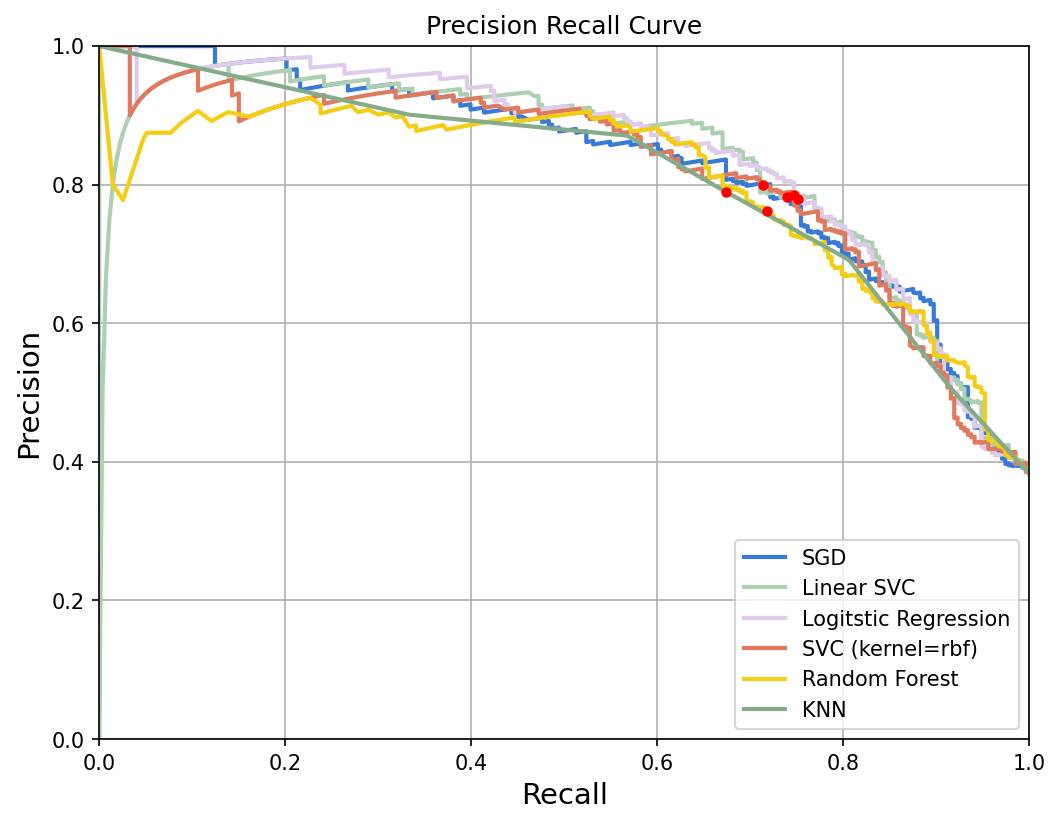

In [36]:
plt.figure(figsize=(8, 6), dpi=150)
plt.axis([0., 1., 0., 1.])
plt.title("Precision Recall Curve")
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)

plt.plot(recs_sgd, precs_sgd, linewidth=2, label="SGD", color="#387ad8")
plt.plot(recs_lin_svc, precs_lin_svc, linewidth=2, label="Linear SVC", color="#add0b3")
plt.plot(recs_logreg, precs_logreg, linewidth=2, label="Logitstic Regression", color="#dfcbeb")
plt.plot(recs_svc, precs_svc, linewidth=2, label="SVC (kernel=rbf)", color="#e07a5f")
plt.plot(recs_rf, precs_rf, linewidth=2, label="Random Forest", color="#f4ce14")
plt.plot(recs_knn, precs_knn, linewidth=2, label="KNN", color="#86ab89")

plt.plot([recall_sgd], [prec_sgd], "ro", markersize=4)
plt.plot([recall_lin_svc], [prec_lin_svc], "ro", markersize=4)
plt.plot([recall_logreg], [prec_logreg], "ro", markersize=4)
plt.plot([recall_knn], [prec_knn], "ro", markersize=4)
plt.plot([recall_svc], [prec_svc], "ro", markersize=4)
plt.plot([recall_rf], [prec_rf], "ro", markersize=4)

plt.legend(loc="lower right")
plt.grid()
plt.show()

### ROC Curve & ROC AUC

In [37]:
from sklearn.metrics import roc_curve

fpr_sgd, tpr_sgd, thresholds_sgd = roc_curve(train_labels_titanic, scores_sgd)
fpr_lin_svc, tpr_lin_svc, thresholds_lin_svc = roc_curve(train_labels_titanic, scores_lin_svc)
fpr_svc, tpr_svc, thresholds_svc = roc_curve(train_labels_titanic, scores_svc)

fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(train_labels_titanic, proba_logreg)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(train_labels_titanic, proba_rf)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(train_labels_titanic, proba_knn)

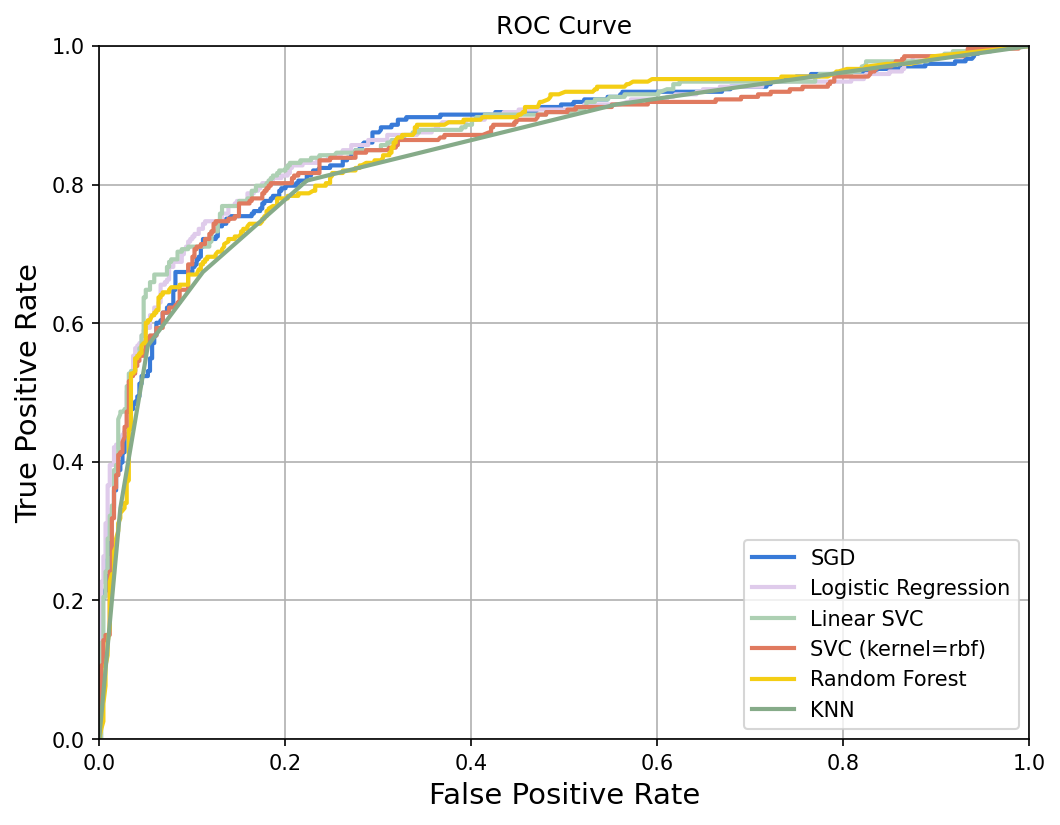

In [38]:
plt.figure(figsize=(8, 6), dpi=150)
plt.axis([0., 1., 0., 1.])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)

plt.plot(fpr_sgd, tpr_sgd, color="#387ad8", linewidth=2, label="SGD")
plt.plot(fpr_logreg, tpr_logreg, color="#dfcbeb", linewidth=2, label="Logistic Regression")
plt.plot(fpr_lin_svc, tpr_lin_svc, color="#add0b3", linewidth=2, label="Linear SVC")
plt.plot(fpr_svc, tpr_svc, color="#e07a5f", linewidth=2, label="SVC (kernel=rbf)")
plt.plot(fpr_rf, tpr_rf, color="#f4ce14", linewidth=2, label="Random Forest")
plt.plot(fpr_knn, tpr_knn, color="#86ab89", linewidth=2, label="KNN")

plt.legend()
plt.grid()
plt.show()

In [39]:
from sklearn.metrics import roc_auc_score

roc_auc_sgd = roc_auc_score(train_labels_titanic, scores_sgd)
roc_auc_lin_svc = roc_auc_score(train_labels_titanic, scores_lin_svc)
roc_auc_svc = roc_auc_score(train_labels_titanic, scores_svc)
roc_auc_logreg = roc_auc_score(train_labels_titanic, proba_logreg)
roc_auc_rf = roc_auc_score(train_labels_titanic, proba_rf)
roc_auc_knn = roc_auc_score(train_labels_titanic, proba_knn)

print(f"ROC AUC SGD: {round(roc_auc_sgd, 2)}")
print(f"ROC AUC Linear SVC: {round(roc_auc_lin_svc, 2)}")
print(f"ROC AUC SVC: {round(roc_auc_svc, 2)}")
print(f"ROC AUC Logistic Regression: {round(roc_auc_logreg, 2)}")
print(f"ROC AUC RF: {round(roc_auc_rf, 2)}")
print(f"ROC AUC KNN: {round(roc_auc_knn, 2)}")

ROC AUC SGD: 0.87
ROC AUC Linear SVC: 0.87
ROC AUC SVC: 0.86
ROC AUC Logistic Regression: 0.87
ROC AUC RF: 0.86
ROC AUC KNN: 0.85


### Confusion Matrix

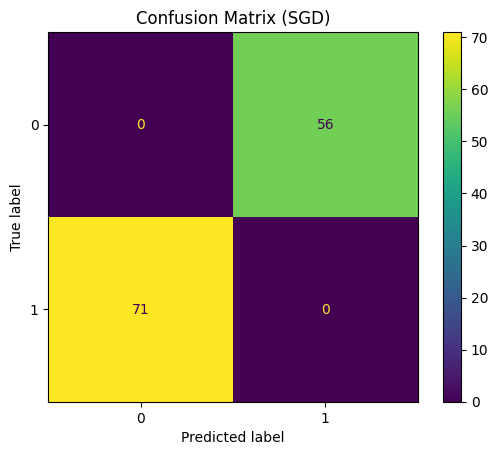

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

sample_weight = (preds_sgd != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_sgd,
                                        sample_weight=sample_weight)
plt.title("Confusion Matrix (SGD)")
plt.show()

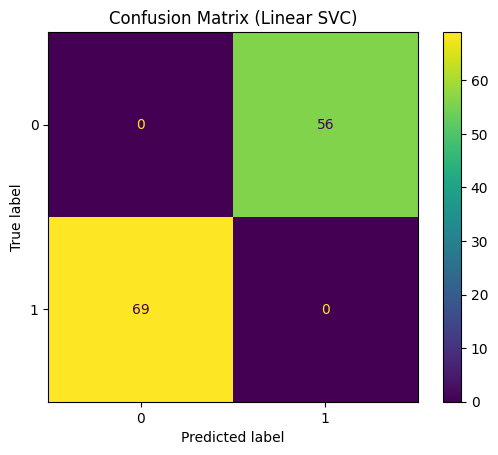

In [41]:
sample_weight = (preds_lin_svc != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_lin_svc,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (Linear SVC)")
plt.show()

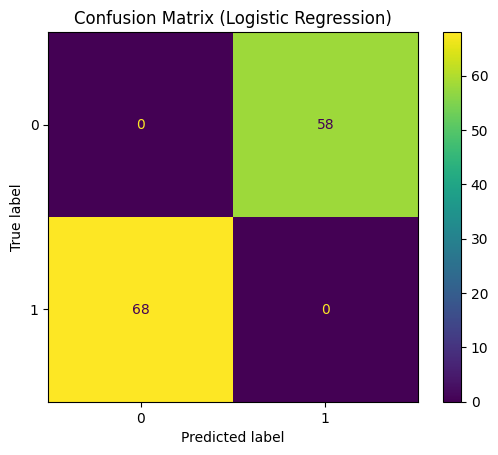

In [42]:
sample_weight = (preds_logreg != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_logreg,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

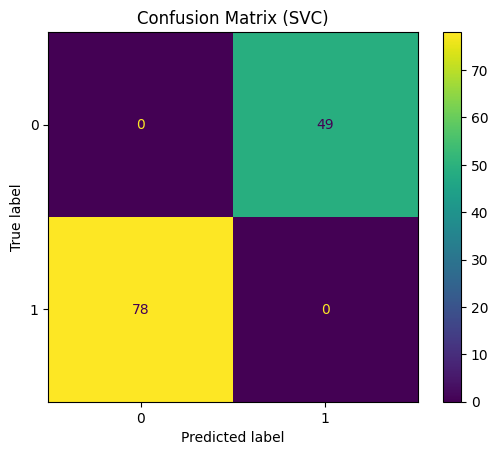

In [43]:
sample_weight = (preds_svc != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_svc,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (SVC)")
plt.show()

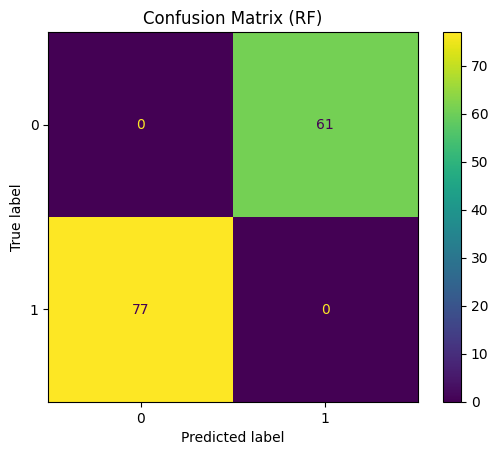

In [44]:
sample_weight = (preds_rf != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_rf,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (RF)")
plt.show()

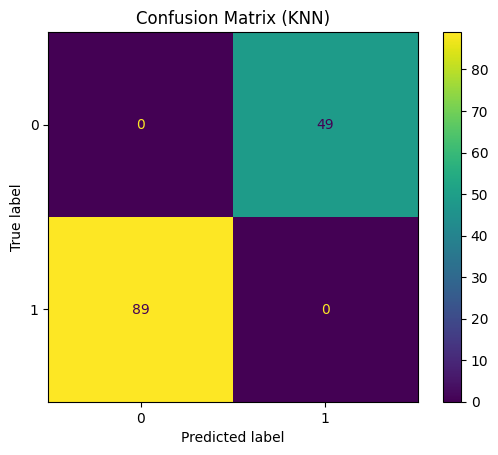

In [45]:
sample_weight = (preds_knn != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_knn,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (KNN)")
plt.show()

In [46]:
import numpy as np

pd.DataFrame({"Model": ["SGD Classifier", "SVC (kernel=rbf)", "Linear SVC", "Logistic Regression", "Random Forest", "KNeighbors Classifier"],
             "Accuracy": np.round([acc_sgd, acc_svc, acc_lin_svc, acc_logreg, acc_rf, acc_knn], decimals=2),
             "Precision": np.round([prec_sgd, prec_svc, prec_lin_svc, prec_logreg, prec_rf, prec_knn], decimals=2),
             "Recall": np.round([recall_sgd, recall_svc, recall_lin_svc, recall_logreg, recall_rf, recall_knn], decimals=2),
             "F1 Score": np.round([f1_sgd, f1_svc, f1_lin_svc, f1_logreg, f1_rf, f1_knn], decimals=2),
             "ROC AUC": np.round([roc_auc_sgd, roc_auc_svc, roc_auc_lin_svc, roc_auc_logreg, roc_auc_rf, roc_auc_knn], decimals=2)})

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SGD Classifier,0.82,0.78,0.74,0.76,0.87
1,SVC (kernel=rbf),0.82,0.80,0.71,0.75,0.86
2,Linear SVC,0.82,0.78,0.75,0.77,0.87
3,Logistic Regression,0.82,0.78,0.75,0.76,0.87
4,Random Forest,0.81,0.76,0.72,0.74,0.86
5,KNeighbors Classifier,0.81,0.79,0.67,0.73,0.85


## Error Analysis

In [47]:
feature_eng = FeatureEngineering()
train_titanic_eng = feature_eng.fit_transform(train_titanic)
train_titanic_eng.head()

,Pclass,Sex,Age,Fare,Embarked,Prefix,Deck,Family Size,Is Alone
692,3,male,NaN,56.4958,S,Mr,Unknown,1,1
481,2,male,NaN,0.0000,S,Mr,Unknown,1,1
527,1,male,NaN,221.7792,S,Mr,C,1,1
855,3,female,18.0,9.3500,S,Mrs,Unknown,2,0
801,2,female,31.0,26.2500,S,Mrs,Unknown,3,0


In [48]:
def error_rate_by_group(df, group_column, y_true, y_pred):
    total = df[group_column].value_counts().sort_index()
    fn = df[(y_true == 1) & (y_pred == 0)][group_column].value_counts().sort_index()
    fp = df[(y_true == 0) & (y_pred == 1)][group_column].value_counts().sort_index()

    res = pd.DataFrame({"Total": total, "FN": fn, "FP": fp}).fillna(0)
    res["FN Rate"] = np.round(res["FN"].values / res["Total"].values, 2)
    res["FP Rate"] = np.round(res["FP"].values / res["Total"].values, 2)
    return res

In [49]:
error_rate_by_group(train_titanic_eng, "Sex", train_labels_titanic, preds_lin_svc)

,Total,FN,FP,FN Rate,FP Rate
Sex,,,,,
female,253,7,45,0.03,0.18
male,459,62,11,0.14,0.02


In [50]:
error_rate_by_group(train_titanic_eng, "Sex", train_labels_titanic, preds_svc)

,Total,FN,FP,FN Rate,FP Rate
Sex,,,,,
female,253,16,38,0.06,0.15
male,459,62,11,0.14,0.02


In [51]:
error_rate_by_group(train_titanic_eng, "Sex", train_labels_titanic, preds_logreg)

,Total,FN,FP,FN Rate,FP Rate
Sex,,,,,
female,253,7,43,0.03,0.17
male,459,61,15,0.13,0.03


In [52]:
error_rate_by_group(train_titanic_eng, "Sex", train_labels_titanic, preds_rf)

,Total,FN,FP,FN Rate,FP Rate
Sex,,,,,
female,253,19,33,0.08,0.13
male,459,58,28,0.13,0.06


In [53]:
error_rate_by_group(train_titanic_eng, "Deck", train_labels_titanic, preds_lin_svc)

,Total,FN,FP,FN Rate,FP Rate
Deck,,,,,
A,14,4.0,0.0,0.29,0.00
B,34,3.0,1.0,0.09,0.03
C,41,7.0,4.0,0.17,0.10
D,26,4.0,3.0,0.15,0.12
E,29,6.0,2.0,0.21,0.07
F,11,0.0,0.0,0.00,0.00
G,4,1.0,2.0,0.25,0.50
T,1,0.0,0.0,0.00,0.00
Unknown,552,44.0,44.0,0.08,0.08


In [54]:
error_rate_by_group(train_titanic_eng, "Deck", train_labels_titanic, preds_svc)

,Total,FN,FP,FN Rate,FP Rate
Deck,,,,,
A,14,4.0,0.0,0.29,0.00
B,34,2.0,0.0,0.06,0.00
C,41,7.0,7.0,0.17,0.17
D,26,6.0,2.0,0.23,0.08
E,29,4.0,2.0,0.14,0.07
F,11,0.0,0.0,0.00,0.00
G,4,1.0,2.0,0.25,0.50
T,1,0.0,0.0,0.00,0.00
Unknown,552,54.0,36.0,0.10,0.07


In [55]:
error_rate_by_group(train_titanic_eng, "Deck", train_labels_titanic, preds_logreg)

,Total,FN,FP,FN Rate,FP Rate
Deck,,,,,
A,14,2.0,0.0,0.14,0.00
B,34,1.0,2.0,0.03,0.06
C,41,5.0,6.0,0.12,0.15
D,26,3.0,2.0,0.12,0.08
E,29,6.0,2.0,0.21,0.07
F,11,0.0,0.0,0.00,0.00
G,4,0.0,2.0,0.00,0.50
T,1,0.0,0.0,0.00,0.00
Unknown,552,51.0,44.0,0.09,0.08


In [56]:
error_rate_by_group(train_titanic_eng, "Deck", train_labels_titanic, preds_rf)

,Total,FN,FP,FN Rate,FP Rate
Deck,,,,,
A,14,2.0,0.0,0.14,0.00
B,34,2.0,0.0,0.06,0.00
C,41,6.0,9.0,0.15,0.22
D,26,7.0,2.0,0.27,0.08
E,29,3.0,5.0,0.10,0.17
F,11,0.0,0.0,0.00,0.00
G,4,0.0,2.0,0.00,0.50
T,1,0.0,0.0,0.00,0.00
Unknown,552,57.0,43.0,0.10,0.08


In [57]:
error_rate_by_group(train_titanic_eng, "Family Size", train_labels_titanic, preds_lin_svc)

,Total,FN,FP,FN Rate,FP Rate
Family Size,,,,,
1,434,46.0,25.0,0.11,0.06
2,129,10.0,18.0,0.08,0.14
3,77,5.0,10.0,0.06,0.13
4,22,1.0,2.0,0.05,0.09
5,14,2.0,0.0,0.14,0.00
6,16,1.0,0.0,0.06,0.00
7,11,4.0,1.0,0.36,0.09
8,4,0.0,0.0,0.00,0.00
11,5,0.0,0.0,0.00,0.00


In [58]:
error_rate_by_group(train_titanic_eng, "Family Size", train_labels_titanic, preds_svc)

,Total,FN,FP,FN Rate,FP Rate
Family Size,,,,,
1,434,52.0,22.0,0.12,0.05
2,129,16.0,13.0,0.12,0.10
3,77,6.0,8.0,0.08,0.10
4,22,1.0,1.0,0.05,0.05
5,14,0.0,0.0,0.00,0.00
6,16,0.0,0.0,0.00,0.00
7,11,3.0,5.0,0.27,0.45
8,4,0.0,0.0,0.00,0.00
11,5,0.0,0.0,0.00,0.00


In [59]:
error_rate_by_group(train_titanic_eng, "Family Size", train_labels_titanic, preds_logreg)

,Total,FN,FP,FN Rate,FP Rate
Family Size,,,,,
1,434,45.0,28.0,0.10,0.06
2,129,11.0,15.0,0.09,0.12
3,77,5.0,10.0,0.06,0.13
4,22,2.0,2.0,0.09,0.09
5,14,1.0,0.0,0.07,0.00
6,16,1.0,0.0,0.06,0.00
7,11,3.0,3.0,0.27,0.27
8,4,0.0,0.0,0.00,0.00
11,5,0.0,0.0,0.00,0.00


In [60]:
error_rate_by_group(train_titanic_eng, "Family Size", train_labels_titanic, preds_rf)

,Total,FN,FP,FN Rate,FP Rate
Family Size,,,,,
1,434,48.0,32.0,0.11,0.07
2,129,16.0,13.0,0.12,0.10
3,77,9.0,9.0,0.12,0.12
4,22,1.0,2.0,0.05,0.09
5,14,0.0,1.0,0.00,0.07
6,16,0.0,0.0,0.00,0.00
7,11,3.0,4.0,0.27,0.36
8,4,0.0,0.0,0.00,0.00
11,5,0.0,0.0,0.00,0.00


In [61]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_lin_svc).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/236578672.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_lin_svc).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Pclass  Sex   
1       female    0.037975
        male      0.369565
2       female    0.120690
        male      0.076087
3       female    0.362069
        male      0.116364
dtype: float64

In [62]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_svc).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/945804310.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_svc).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Pclass  Sex   
1       female    0.037975
        male      0.358696
2       female    0.086207
        male      0.076087
3       female    0.396552
        male      0.120000
dtype: float64

In [63]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_logreg).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/1228531836.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_logreg).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Pclass  Sex   
1       female    0.025316
        male      0.358696
2       female    0.137931
        male      0.076087
3       female    0.344828
        male      0.130909
dtype: float64

In [64]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_rf).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/2570418831.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_rf).groupby(["Pclass", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Pclass  Sex   
1       female    0.025316
        male      0.380435
2       female    0.103448
        male      0.076087
3       female    0.379310
        male      0.160000
dtype: float64

In [65]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_lin_svc).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/304619525.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_lin_svc).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Deck     Sex   
A        female    0.000000
         male      0.307692
B        female    0.045455
         male      0.250000
C        female    0.095238
         male      0.450000
D        female    0.000000
         male      0.583333
E        female    0.071429
         male      0.466667
F        female    0.000000
         male      0.000000
G        female    0.750000
T        male      0.000000
Unknown  female    0.261628
         male      0.113158
dtype: float64

In [66]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_svc).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/3773271874.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_svc).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Deck     Sex   
A        female    0.000000
         male      0.307692
B        female    0.000000
         male      0.166667
C        female    0.142857
         male      0.550000
D        female    0.000000
         male      0.666667
E        female    0.071429
         male      0.333333
F        female    0.000000
         male      0.000000
G        female    0.750000
T        male      0.000000
Unknown  female    0.273256
         male      0.113158
dtype: float64

In [67]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_logreg).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/1054634117.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_logreg).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Deck     Sex   
A        female    0.000000
         male      0.153846
B        female    0.000000
         male      0.250000
C        female    0.095238
         male      0.450000
D        female    0.000000
         male      0.416667
E        female    0.071429
         male      0.466667
F        female    0.000000
         male      0.000000
G        female    0.500000
T        male      0.000000
Unknown  female    0.261628
         male      0.131579
dtype: float64

In [68]:
train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_rf).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())

/tmp/ipykernel_58/1724401435.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_titanic_eng.assign(labels=train_labels_titanic, preds=preds_rf).groupby(["Deck", "Sex"]).apply(lambda g: (g["labels"] != g["preds"]).mean())


Deck     Sex   
A        female    0.000000
         male      0.153846
B        female    0.000000
         male      0.166667
C        female    0.095238
         male      0.650000
D        female    0.000000
         male      0.750000
E        female    0.071429
         male      0.466667
F        female    0.000000
         male      0.000000
G        female    0.500000
T        male      0.000000
Unknown  female    0.273256
         male      0.139474
dtype: float64

In [69]:
lin_svc_1_0 = train_titanic_eng[(train_labels_titanic == 1) & (preds_lin_svc == 0)]
rf_1_0 = train_titanic_eng[(train_labels_titanic == 1) & (preds_rf == 0)]
svc_1_0 = train_titanic_eng[(train_labels_titanic == 1) & (preds_svc == 0)]

lin_svc_0_1 = train_titanic_eng[(train_labels_titanic == 0) & (preds_lin_svc == 1)]
rf_0_1 = train_titanic_eng[(train_labels_titanic == 0) & (preds_rf == 1)]
svc_0_1 = train_titanic_eng[(train_labels_titanic == 0) & (preds_svc == 1)]

print(train_titanic_eng.loc[lin_svc_1_0.index]["Age"].describe(),
     train_titanic_eng.loc[rf_1_0.index]["Age"].describe(),
     train_titanic_eng.loc[svc_1_0.index]["Age"].describe(), sep="\n\n")

count    59.000000
mean     32.101695
std      13.809910
min       3.000000
25%      24.000000
50%      32.000000
75%      41.000000
max      80.000000
Name: Age, dtype: float64

count    63.000000
mean     30.158730
std      12.846747
min       3.000000
25%      20.000000
50%      29.000000
75%      36.500000
max      80.000000
Name: Age, dtype: float64

count    65.000000
mean     30.861538
std      13.992048
min       3.000000
25%      20.000000
50%      30.000000
75%      39.000000
max      80.000000
Name: Age, dtype: float64


In [70]:
print(train_titanic_eng.loc[lin_svc_0_1.index]["Age"].describe(),
     train_titanic_eng.loc[rf_0_1.index]["Age"].describe(),
     train_titanic_eng.loc[svc_0_1.index]["Age"].describe(), sep="\n\n")

count    47.000000
mean     26.808511
std      12.101722
min       2.000000
25%      18.500000
50%      25.000000
75%      31.500000
max      57.000000
Name: Age, dtype: float64

count    52.000000
mean     28.317308
std      14.555852
min       2.000000
25%      18.000000
50%      27.500000
75%      38.250000
max      57.000000
Name: Age, dtype: float64

count    42.000000
mean     27.130952
std      14.496450
min       2.000000
25%      18.000000
50%      26.000000
75%      38.750000
max      57.000000
Name: Age, dtype: float64


In [71]:
cond_lin_svc = preds_lin_svc == train_labels_titanic
cond_svc = preds_svc == train_labels_titanic
cond_rf = preds_rf == train_labels_titanic

common_errors = ((~cond_lin_svc) & (~cond_svc) & (~cond_rf)).sum()
only_lin_svc_errors = ((~cond_lin_svc) & (cond_svc) & (cond_rf)).sum()
only_svc_errors = ((cond_lin_svc) & (~cond_svc) & (cond_rf)).sum()
only_rf_errors = ((cond_lin_svc) & (cond_svc) & (~cond_rf)).sum()

print(f"Common errors: {common_errors}")
print(f"Linear SVC errors: {only_lin_svc_errors}")
print(f"SVC (kernel=rbf) errors: {only_svc_errors}")
print(f"Random Forest errors: {only_rf_errors}")

Common errors: 84
Linear SVC errors: 19
SVC (kernel=rbf) errors: 7
Random Forest errors: 28


## Hyperparameter Tuning

In [72]:
import warnings
warnings.filterwarnings("ignore")

In [73]:
full_pipeline_svc = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    SVC(kernel="rbf", random_state=42)
)

In [74]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, expon

param_distribs = {
    "columntransformer__num_pipeline__fill_missing_values__strategy": ["mean", "median"],
    "svc__C": reciprocal(1e-2, 1e3),
    "svc__gamma": expon(scale=1.0)
}

random_search_svc = RandomizedSearchCV(
    full_pipeline_svc,
    param_distributions=param_distribs,
    n_iter=20,
    scoring="accuracy",
    verbose=1,
    random_state=42
)
random_search_svc.fit(train_titanic, train_labels_titanic)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(estimator=Pipeline(steps=[('featureengineering',
                                              FeatureEngineering()),
                                             ('columntransformer',
                                              ColumnTransformer(transformers=[('num_pipeline',
                                                                               Pipeline(steps=[('fill_missing_values',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('std_scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Fare']),
                                                                              ('cats',
                                                                               Pipeline(steps=[('fill_most_frequent_missing_values',
                                                                                                SimpleIm...
                                             ('svc', SVC(random_state=42))]),
                   n_iter=20,
                   param_distributions={'columntransformer__num_pipeline__fill_missing_values__strategy': ['mean',
                                                                                                           'median'],
                                        'svc__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c873cfabda0>,
                                        'svc__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c873d1889e0>},
                   random_state=42, scoring='accuracy', verbose=1)

In [75]:
full_pipeline_rf = make_pipeline(
    FeatureEngineering(),
    preprocessor_without_scaler,
    RandomForestClassifier(random_state=42)
)

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"columntransformer__fill_missing_num__strategy": ["mean", "median"],
     "randomforestclassifier__n_estimators": [100, 200, 500], 
     "randomforestclassifier__max_features": [1, 2, 3, 4, 5],
     "randomforestclassifier__max_depth": [None, 10, 15, 20],
     "randomforestclassifier__min_samples_leaf": [1, 10, 20]}
]

grid_search = GridSearchCV(
    full_pipeline_rf,
    param_grid,
    cv=3,
    scoring="accuracy",
    verbose=1
)
grid_search.fit(train_titanic, train_labels_titanic)

Fitting 3 folds for each of 360 candidates, totalling 1080 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('featureengineering',
                                        FeatureEngineering()),
                                       ('columntransformer',
                                        ColumnTransformer(transformers=[('fill_missing_num',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['Age']),
                                                                        ('cats',
                                                                         Pipeline(steps=[('fill_most_frequent_missing_values',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('cats_encoders',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        h...
                                        RandomForestClassifier(random_state=42))]),
             param_grid=[{'columntransformer__fill_missing_num__strategy': ['mean',
                                                                            'median'],
                          'randomforestclassifier__max_depth': [None, 10, 15,
                                                                20],
                          'randomforestclassifier__max_features': [1, 2, 3, 4,
                                                                   5],
                          'randomforestclassifier__min_samples_leaf': [1, 10,
                                                                       20],
                          'randomforestclassifier__n_estimators': [100, 200,
                                                                   500]}],
             scoring='accuracy', verbose=1)

In [77]:
full_pipeline_lin_svc = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    LinearSVC(random_state=42)
)

param_distribs = {
    "linearsvc__C": reciprocal(1e-2, 1e3)
}

random_search_lin_svc = RandomizedSearchCV(
    full_pipeline_lin_svc,
    param_distributions=param_distribs,
    n_iter=20,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
random_search_lin_svc.fit(train_titanic, train_labels_titanic)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(estimator=Pipeline(steps=[('featureengineering',
                                              FeatureEngineering()),
                                             ('columntransformer',
                                              ColumnTransformer(transformers=[('num_pipeline',
                                                                               Pipeline(steps=[('fill_missing_values',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('std_scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Fare']),
                                                                              ('cats',
                                                                               Pipeline(steps=[('fill_most_frequent_missing_values',
                                                                                                SimpleIm...
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['Sex',
                                                                                'Embarked',
                                                                                'Prefix',
                                                                                'Deck',
                                                                                'Family '
                                                                                'Size']),
                                                                              ('keep',
                                                                               'passthrough',
                                                                               ['Pclass',
                                                                                'Is '
                                                                                'Alone'])])),
                                             ('linearsvc',
                                              LinearSVC(random_state=42))]),
                   n_iter=20,
                   param_distributions={'linearsvc__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c873d135520>},
                   random_state=42, scoring='accuracy', verbose=1)

In [78]:
full_pipeline_logreg = make_pipeline(
    FeatureEngineering(),
    preprocessor_with_scaler,
    LogisticRegression(random_state=42)
)

param_distribs = {
    "logisticregression__C": reciprocal(1e-2, 1e3)
}

random_search_logreg = RandomizedSearchCV(
    full_pipeline_logreg,
    param_distributions=param_distribs,
    n_iter=20,
    scoring="accuracy",
    random_state=41,
    verbose=1
)

random_search_logreg.fit(train_titanic, train_labels_titanic)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(estimator=Pipeline(steps=[('featureengineering',
                                              FeatureEngineering()),
                                             ('columntransformer',
                                              ColumnTransformer(transformers=[('num_pipeline',
                                                                               Pipeline(steps=[('fill_missing_values',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('std_scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Fare']),
                                                                              ('cats',
                                                                               Pipeline(steps=[('fill_most_frequent_missing_values',
                                                                                                SimpleIm...
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['Sex',
                                                                                'Embarked',
                                                                                'Prefix',
                                                                                'Deck',
                                                                                'Family '
                                                                                'Size']),
                                                                              ('keep',
                                                                               'passthrough',
                                                                               ['Pclass',
                                                                                'Is '
                                                                                'Alone'])])),
                                             ('logisticregression',
                                              LogisticRegression(random_state=42))]),
                   n_iter=20,
                   param_distributions={'logisticregression__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c873f6d4950>},
                   random_state=41, scoring='accuracy', verbose=1)

In [79]:
best_pipeline_svc = random_search_svc.best_estimator_
best_pipeline_rf = grid_search.best_estimator_
best_pipeline_lin_svc = random_search_lin_svc.best_estimator_
best_pipeline_logreg = random_search_logreg.best_estimator_

In [80]:
svc_preds = best_pipeline_svc.predict(train_titanic)
rf_preds = best_pipeline_rf.predict(train_titanic)
lin_svc_preds = best_pipeline_lin_svc.predict(train_titanic)
logreg_preds = best_pipeline_logreg.predict(train_titanic)

In [81]:
acc_svc, prec_svc, recall_svc, f1_svc = compute_scores(train_labels_titanic, svc_preds)
acc_rf, prec_rf, recall_rf, f1_rf = compute_scores(train_labels_titanic, rf_preds)
acc_lin_svc, prec_lin_svc, recall_lin_svc, f1_lin_svc = compute_scores(train_labels_titanic, lin_svc_preds)
acc_logreg, prec_logreg, recall_logreg, f1_logreg = compute_scores(train_labels_titanic, logreg_preds)

In [82]:
display_scores("SVC (kernel=rbf)", acc_svc, prec_svc, recall_svc, f1_svc)
display_scores("Random Forest", acc_rf, prec_rf, recall_rf, f1_rf)
display_scores("Linear SVC", acc_lin_svc, prec_lin_svc, recall_lin_svc, f1_lin_svc)
display_scores("Logistic Regression", acc_logreg, prec_logreg, recall_logreg, f1_logreg)

Model: SVC (kernel=rbf)
Accuracy: 0.89
Precision: 0.91
Recall: 0.79
F1 Score: 0.84

Model: Random Forest
Accuracy: 0.94
Precision: 0.97
Recall: 0.88
F1 Score: 0.92

Model: Linear SVC
Accuracy: 0.84
Precision: 0.8
Recall: 0.78
F1 Score: 0.79

Model: Logistic Regression
Accuracy: 0.84
Precision: 0.81
Recall: 0.78
F1 Score: 0.79



In [83]:
svc_scores = best_pipeline_svc.decision_function(train_titanic)
lin_svc_scores = best_pipeline_lin_svc.decision_function(train_titanic)
rf_proba = best_pipeline_rf.predict_proba(train_titanic)[:, 1]
logreg_proba = best_pipeline_logreg.predict_proba(train_titanic)[:, 1]

roc_auc_svc = roc_auc_score(train_labels_titanic, svc_scores)
roc_auc_lin_svc = roc_auc_score(train_labels_titanic, lin_svc_scores)
roc_auc_rf = roc_auc_score(train_labels_titanic, rf_proba)
roc_auc_logreg = roc_auc_score(train_labels_titanic, logreg_proba)

print(f"ROC AUC SVC: {round(roc_auc_svc, 2)}")
print(f"ROC AUC Linear SVC: {round(roc_auc_lin_svc, 2)}")
print(f"ROC AUC RF: {round(roc_auc_rf, 2)}")
print(f"ROC AUC Logistic Regression: {round(roc_auc_logreg, 2)}")

ROC AUC SVC: 0.93
ROC AUC Linear SVC: 0.88
ROC AUC RF: 0.98
ROC AUC Logistic Regression: 0.88


## Final Model

In [84]:
test_titanic = test_strat.drop("Survived", axis=1)
test_titanic_labels = test_strat["Survived"]

In [85]:
rf_test_preds = best_pipeline_rf.predict(test_titanic)
test_acc_rf, test_prec_rf, test_recall_rf, test_f1_rf = compute_scores(test_titanic_labels, rf_test_preds)
display_scores("Random Forest (Test set)", test_acc_rf, test_prec_rf, test_recall_rf, test_f1_rf)

Model: Random Forest (Test set)
Accuracy: 0.8
Precision: 0.78
Recall: 0.68
F1 Score: 0.73



In [86]:
rf_proba = best_pipeline_rf.predict_proba(test_titanic)[:, 1]
roc_auc_rf = roc_auc_score(test_titanic_labels, rf_proba)

print(f"ROC AUC RF: {round(roc_auc_rf, 2)}")

ROC AUC RF: 0.84


In [87]:
svc_test_preds = best_pipeline_svc.predict(test_titanic)
test_acc_svc, test_prec_svc, test_recall_svc, test_f1_svc = compute_scores(test_titanic_labels, svc_test_preds)
display_scores("SVC (Test set)", test_acc_svc, test_prec_svc, test_recall_svc, test_f1_svc)

Model: SVC (Test set)
Accuracy: 0.8
Precision: 0.78
Recall: 0.68
F1 Score: 0.73



In [88]:
svc_scores = best_pipeline_svc.decision_function(test_titanic)
roc_auc_svc = roc_auc_score(test_titanic_labels, svc_scores)

print(f"ROC AUC SVC: {round(roc_auc_svc, 2)}")

ROC AUC SVC: 0.82


## Feature Importance

In [130]:
feature_imp_newp_rf = Pipeline(best_pipeline_rf.steps[1:])
test_feature_rf_eng = best_pipeline_rf.steps[0][1].transform(test_titanic)

In [139]:
from sklearn.inspection import permutation_importance

importance_rf = permutation_importance(
    feature_imp_newp_rf, test_feature_rf_eng, test_titanic_labels,
    n_repeats=10, random_state=42, scoring="accuracy"
)

pd.DataFrame({"Importance mean": importance_rf.importances_mean, 
              "Importance std": importance_rf.importances_std},
              index=test_feature_rf_eng.columns)

,Importance mean,Importance std
Pclass,0.036313,0.012047
Sex,0.089385,0.025723
Age,0.034637,0.012442
Fare,-0.010615,0.008815
Embarked,0.002793,0.013279
Prefix,0.038547,0.020366
Deck,0.001676,0.008305
Family Size,0.008380,0.007599
Is Alone,-0.005028,0.007263


In [134]:
feature_imp_newp_svc = Pipeline(best_pipeline_svc.steps[1:])
test_feature_svc_eng = best_pipeline_svc.steps[0][1].transform(test_titanic)

In [140]:
importance_svc = permutation_importance(
    feature_imp_newp_svc, test_feature_svc_eng, test_titanic_labels,
    n_repeats=10, random_state=42, scoring="accuracy"
)
pd.DataFrame({"Importance mean": importance_svc.importances_mean,
             "Importance std": importance_svc.importances_std},
             index=test_feature_svc_eng.columns)

,Importance mean,Importance std
Pclass,0.036313,0.012047
Sex,0.035754,0.017345
Age,0.035754,0.013730
Fare,0.030726,0.011243
Embarked,0.019553,0.012303
Prefix,0.118436,0.034870
Deck,-0.012291,0.011117
Family Size,0.024581,0.013955
Is Alone,-0.002793,0.007176


## Kaggle Submission

Use the *RF* model to generate predictions for `test.csv`

In [89]:
final_test_titanic = load_titanic_data("/kaggle/input/competitions/titanic/test.csv")
final_test_titanic.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [90]:
final_test_titanic.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [91]:
final_test_titanic["Fare"] = final_test_titanic["Fare"].fillna(final_test_titanic["Fare"].median())

In [92]:
final_predictions = best_pipeline_rf.predict(final_test_titanic)
final_predictions[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0])

In [93]:
final_preds = pd.DataFrame({
    "PassengerId": list(final_test_titanic["PassengerId"].values),
    "Survived": list(final_predictions)
})

final_preds

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [94]:
final_preds.to_csv("submission.csv", index=False)

## Conclusion

In this project:

- Explored the Titanic dataset
- Preprocessed the data
- Compared multiple ML models
- Analyzed prediction errors
- Tuned the best model
- Generated the final Kaggle submission